# Import

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [2]:
import torch
import numpy as np

In [3]:
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torchvision import transforms


In [4]:
import albumentations as albu
from PIL import Image


In [5]:
from torch.utils.data import Dataset
from typing import Union,List,Tuple
import pathlib
from timeit import default_timer as timer
from torch.utils.data import DataLoader
import h5py
from tqdm import tqdm
import torchvision
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import time
from torch.utils.tensorboard import SummaryWriter

In [6]:
# mlfmow library
import mlflow
import mlflow.pytorch
import shutil


# MLflow run

In [7]:
from mlflow.exceptions import MlflowException
import datetime

# End MLflow run
mlflow.end_run()

# Function to generate a unique experiment name
def generate_experiment_name():
    return f"experiment-{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"

# Function to create and set a new experiment
def set_experiment(experiment_name):
    try:
        experiment = mlflow.get_experiment_by_name(experiment_name)
        if experiment is None:
            mlflow.create_experiment(experiment_name)
            experiment = mlflow.get_experiment_by_name(experiment_name)
        mlflow.set_experiment(experiment_name)
    except MlflowException as e:
        print(f"Error setting experiment: {e}")
        
        
# Generate a unique experiment name and set the experiment
experiment_name = generate_experiment_name()
set_experiment(experiment_name)

# Verify the experiment is set correctly
print(f"Set experiment '{experiment_name}'")


# Start an MLflow run
mlflow.start_run(run_name=f"training_adapted-{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Unique runs directory
runs_dir = os.path.join("runs", experiment_name, datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S'))



Set experiment 'experiment-2024-07-16_16-25-35'


In [8]:
#Put the device on GPU if possible to train the model faster than with CPU

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Log device information
mlflow.log_param("device", "cuda:0" if torch.cuda.is_available() else "cpu")

batch_size = 32
period_size = 8
weight_decay = 0.1
epsilon = 10**(-8)
epochs_num = 4
learning_rate = 10**(-3)
n_channel = 3   # 3 RGB channels 
class_num = 3

label_dir = "D:/Donnees_pour_segmentation_RDN/data/ROU_2006/Label"
input_dir =  "D:/Donnees_pour_segmentation_RDN/data/ROU_2006/Unseg"
new_label_dir = "D:/Donnees_pour_segmentation_RDN/data/ROU_2006_mini/Label"
new_input_dir = "D:/Donnees_pour_segmentation_RDN/data/ROU_2006_mini/Unseg"

runs_dir = os.path.join("runs", datetime.datetime.now().strftime('%Y-%m-%d%H-%M-%S'))

stride = 32
train_size = 0.7

output = 256

# Log parameters
mlflow.log_param("batch_size", batch_size)
mlflow.log_param("period_size", period_size)
mlflow.log_param("weight_decay", weight_decay)
mlflow.log_param("epsilon", epsilon)
mlflow.log_param("epochs_num", epochs_num)
mlflow.log_param("learning_rate", learning_rate)
mlflow.log_param("runs_dir", runs_dir)
mlflow.log_param("n_channel", n_channel)
mlflow.log_param("class_num", class_num)
mlflow.log_param("label_dir", label_dir)
mlflow.log_param("input_dir", input_dir)
mlflow.log_param("stride", stride)
mlflow.log_param("train_size", train_size)
mlflow.log_param("output", output)

# Initialize TensorBoard writer
writer = SummaryWriter(runs_dir)

# Select files

In [9]:
# Ensure the new directories exist
os.makedirs(new_label_dir, exist_ok=True)
os.makedirs(new_input_dir, exist_ok=True)

# Function to empty the destination directories
def empty_directory(directory):
    for filename in os.listdir(directory):
        file_path = os.path.join(directory, filename)
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)

# Function to copy files
def copy_files(file_paths, destination_dir):
    for file_path in file_paths:
        shutil.copy(file_path, destination_dir)

# Function to get the number of digits in the file names
def get_num_digits(directory):
    files = [f for f in os.listdir(directory) if f.endswith('.tif')]
    if not files:
        raise ValueError("No .tif files found in the directory")
    num_digits = len(files[0].split('_')[-1].split('.')[0])
    return num_digits

# Function to get image files by index range
def get_image_files_by_index(directory, start_index, end_index):
    num_digits = get_num_digits(directory)
    image_files = []
    for idx in range(start_index, end_index + 1):
        file_name = f"{directory}/ROU_2006_{idx:0{num_digits}}.tif"
        if os.path.exists(file_name):
            image_files.append(file_name)
        else:
            print(f"File not found: {file_name}")
    return image_files

# Empty the destination directories
empty_directory(new_label_dir)
empty_directory(new_input_dir)

start_index = 800
end_index = 850

# Get the list of image files
label_files = get_image_files_by_index(label_dir, start_index, end_index)
input_files = get_image_files_by_index(input_dir, start_index, end_index)

# Copy the files to the new directories
copy_files(label_files, new_label_dir)
copy_files(input_files, new_input_dir)

print("Files copied successfully!")

# Validate copied files
def validate_files(directory):
    files = os.listdir(directory)
    if not files:
        print(f"No files found in {directory}")
    else:
        print(f"Found {len(files)} files in {directory}")

validate_files(new_label_dir)
validate_files(new_input_dir)


Files copied successfully!
Found 51 files in D:/Donnees_pour_segmentation_RDN/data/ROU_2006_mini/Label
Found 51 files in D:/Donnees_pour_segmentation_RDN/data/ROU_2006_mini/Unseg


# Dataset

In [10]:
class HDF52D(Dataset):
    def __init__(self, patches, mode='train', transform=None):
        self.patches = patches
        self.mode = mode
        self.transform = transform

    def __getitem__(self, idx):
        p = self.patches[idx]
        filename = p[0]
        top, left, height, width = int(p[1]), int(p[2]), int(p[3]), int(p[4])
        image_index = int(filename.split('_')[-1].split('.')[0])

        image_path = os.path.join(new_input_dir, filename)
        neighbor_paths = get_neighbor_paths(image_index, new_input_dir)

        try:
            full_image = load_2_5D_image(image_path, neighbor_paths)
            image = full_image[top:top + height, left:left + width]
        except FileNotFoundError as e:
            print(f"Error loading image: {e}")
            raise e

        label_path = os.path.join(new_label_dir, filename)
        label = Image.open(label_path).convert('L')
        label = np.array(label)[top:top + height, left:left + width]

        sample = {'image': image, 'mask': label}

        if self.transform is not None:
            sample = self.transform(sample)

        return sample

    def __len__(self):
        return len(self.patches)

    def set_mode(self, mode):
        self.mode = mode

def set_dataset_mode(dataset, mode):
    if isinstance(dataset, HDF52D):
        dataset.set_mode(mode)
    else:
        raise TypeError("The dataset must be an instance of the HDF52D class.")



def load_patches(patches):
    if isinstance(patches, pd.DataFrame):
        patches_list = patches.values.tolist()
    else:
        patches_list = patches
    return patches_list


# Dataprocess

In [11]:
def get_neighbor_paths(image_index, directory):
    neighbors = [
        image_index - 1 if image_index > start_index else None,
        image_index,
        image_index + 1 if image_index < end_index else None
    ]
    neighbor_paths = [os.path.join(directory, f"ROU_2006_{n:04d}.tif") if n else None for n in neighbors]
    return neighbor_paths



def load_2_5D_image(image_path, neighbor_paths):
    #print(f"Loading 2.5D image with base path {image_path} and neighbors {neighbor_paths}")  # Debugging line
    images = [Image.open(p).convert('L') for p in [image_path] + neighbor_paths if p is not None]
    image_stack = np.stack([np.array(img) for img in images], axis=-1)

    # Ensure only three channels (previous, current, next)
    if image_stack.shape[-1] > 3:
        image_stack = image_stack[..., :3]

    return image_stack







def create_one_hot(mask, num_classes=3):
    one_hot_mask = torch.zeros((mask.size(0), num_classes, mask.size(1), mask.size(2)), dtype=torch.float32).to(mask.device)
    one_hot_mask = one_hot_mask.scatter(1, mask.unsqueeze(1), 1.0)
    return one_hot_mask


def adjustMask(mask, class_num):
    interval = int(256.0 / class_num)
    new_mask = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.longlong)
    for i in range(class_num):
        if i <= class_num - 2:
            new_mask[(mask >= i*interval) & (mask < (i+1) * interval)] = i
        else:
            new_mask[i*interval <= mask] = i
    return new_mask

class AdjustMask(object):
    def __init__(self, class_num=3):
        self.class_num = class_num

    def __call__(self, sample):
        sample['mask'] = adjustMask(sample['mask'], self.class_num)
        return sample


class ToTensor(object):
    def __init__(self, if_multi_img=False):
        self.if_multi_img = if_multi_img

    def __call__(self, sample):
        image, mask = sample['image'], sample['mask']
        if not self.if_multi_img:
            if len(image.shape) == 2:
                image = np.expand_dims(image, axis=2)
            image = image.transpose((2, 0, 1))
        else:
            if len(image.shape) == 3:
                image = np.expand_dims(image, axis=3)
            image = image.transpose((0, 3, 1, 2))
        sample['image'] = torch.from_numpy(image)
        sample['mask'] = torch.from_numpy(mask)
        if 'weights' in sample:
            sample['weights'] = torch.from_numpy(sample['weights'])
        if 'ratio' in sample:
            sample['ratio'] = torch.from_numpy(sample['ratio'])
        return sample

class Normalize(object):
    def __init__(self, max=255.0, min=0.0, tg_max=1.0, tg_min=0.0):
        self.max = max
        self.min = min
        self.tg_max = tg_max
        self.tg_min = tg_min

    def __call__(self, sample):
        image = sample['image'].astype('float32')
        image = self.tg_min + ((image - self.min)*(self.tg_max - self.tg_min)) / (self.max - self.min)
        sample['image'] = image
        return sample

class Augmentation(object):
    def __init__(self, output_size=256):
        self.aug = albu.Compose([
            albu.OneOf([
                albu.HorizontalFlip(p=1),
                albu.VerticalFlip(p=1),   
                albu.Compose([
                    albu.HorizontalFlip(p=1),
                    albu.VerticalFlip(p=1), 
                ])
            ], p=0.75),
            albu.RandomRotate90(p=1),
            albu.Resize(output_size, output_size, always_apply=True),
        ])
    def __call__(self, sample):
        augmented = self.aug(image=sample['image'], mask=sample['mask'])
        sample['image'] = augmented['image']
        sample['mask'] = augmented['mask']
        return sample




# Generate Patches

In [12]:
#get_minimum_dirt_patches create a subset of initial patches focusing on patches containing dirt (depending on dirt_rate)
# Input :
# dirt_choose_threshold: A threshold value for the dirt ratio to determine whether a patch is considered as a dirt patch.
# dirt_rate: The desired proportion of dirt patches in the selected subset.
# patches: A NumPy array containing information about patches (name, top, left, height, width).
# ratios: A NumPy array containing ratios for each patch (class ratios).
#
# Output :
# returns a subset of initial patches
def get_minimum_dirt_patches(dirt_choose_threshold: float, dirt_rate: float, patches: np.array, ratios: np.array):
    # Start a nested MLflow run for this function
    with mlflow.start_run(nested=True, run_name="get_minimum_dirt_patches"):
        # Log parameters
        mlflow.log_param("dirt_choose_threshold", dirt_choose_threshold)
        mlflow.log_param("dirt_rate", dirt_rate)
        
        # get ratios
        ratios = np.array(ratios)
        # get index that would sort ratios by decreasing order
        ratios_idx = np.argsort(-ratios, axis=0)

        # ratios dimension is n_patches x n_classes
        # get the second column of ratio_idx which is the dirt index sorted by decreasing order
        dirt_idx = ratios_idx[:, 1]

        # get only the patches that dirt ratio is > dirt_choose_threshold
        last_idx = 0
        for i in range(dirt_idx.shape[0]):
            dirt_ratio = ratios[dirt_idx[i], 1]
            if dirt_ratio < dirt_choose_threshold:
                last_idx = i
                break
        
        # indexes of wanted dirt_patches
        dirt_patches_idx = dirt_idx[0:last_idx]
        # indexes of other patches
        rest_idx = dirt_idx[last_idx:-1]

        if not (dirt_rate == 0):
            rest_num = round(((last_idx - 1) / dirt_rate) * (1 - dirt_rate))
            if rest_num > rest_idx.shape[0]:
                rest_num = rest_idx.shape[0]
        else:
            rest_num = rest_idx.shape[0]
        
        # Getting picking other patches
        random_idx = np.random.choice(rest_idx.shape[0], size=rest_num, replace=False)
        non_dirt_patches_idx = rest_idx[random_idx]

        # Getting the final patches
        patches_idx = np.concatenate((dirt_patches_idx, non_dirt_patches_idx), axis=0)
        new_patches = np.asarray(patches)[patches_idx, :].tolist()

        new_patches = shuffle(new_patches)
        new_patches = [[name, int(top), int(left), int(h), int(w)] for [name, top, left, h, w] in new_patches]
        
        # Log the number of patches generated
        mlflow.log_metric("num_dirt_patches", len(dirt_patches_idx))
        mlflow.log_metric("num_non_dirt_patches", len(non_dirt_patches_idx))
        
        return new_patches


#get_dirt_bone_patches create a subset of initial patches focusing on patches containing air (depending on air_rate)
# Input :
# patches: A NumPy array containing information about patches (name, top, left, height, width).
# ratios: A NumPy array containing ratios for each patch (class ratios).
# air_rate: The desired proportion of air patches in the selected subset.
#
# Output :
# returns a list of extracted patches based on the specified conditions and an index representing the length of this list
def get_dirt_bone_patches(patches: np.array, ratios: np.array, air_rate: float):
    # Start a nested MLflow run for this function
    with mlflow.start_run(nested=True, run_name="get_dirt_bone_patches"):
        # get ratios 
        ratios = np.array(ratios)
        # get indices that would sort ratios by decreasing order
        ratios_idx = np.argsort(-ratios, axis=0) 

        # get the second column of ratio_idx which is the dirt index sorted by decreasing order
        dirt_idx = ratios_idx[:, 1]
        # get patches 
        patches = np.asarray(patches)

        # get ratios and patches sorted by decreasing dirt ratios 
        ratios_sort = ratios[dirt_idx, :]
        patches_sort = patches[dirt_idx, :]
        
        dirt_patches = []
        bone_patches = []
        
        while (len(dirt_patches) < 128 or len(bone_patches) < 128) and air_rate < 1:  # in the case that we have not enough patches 
            dirt_patches = []
            bone_patches = []
            # get patches that contains significant differences between dirt and bone ratios (>0.1)
            for idx in range(ratios_sort.shape[0]):
                if (ratios_sort[idx, 0] < air_rate):
                    if (ratios_sort[idx, 1] - ratios_sort[idx, 2] > 0.15):
                        dirt_patches.append(patches_sort[idx, :].tolist())
                    elif (ratios_sort[idx, 2] - ratios_sort[idx, 1] > 0.15):
                        bone_patches.append(patches_sort[idx, :].tolist())
                else:
                    pass
            air_rate += 0.1

        dirt_len = len(dirt_patches)
        bone_len = len(bone_patches)

        bone_index = [1 for i in range(bone_len)]
        dirt_index = [0 for i in range(dirt_len)]
        
        dirt_patches = shuffle(dirt_patches)
        bone_patches = shuffle(bone_patches)

        print(f"There are {bone_len} bone and {dirt_len} dirt patches in the training data...")
        
        # Log the number of patches generated
        mlflow.log_metric("num_dirt_patches", dirt_len)
        mlflow.log_metric("num_bone_patches", bone_len)

        end_idx = dirt_len if dirt_len < bone_len else bone_len
        # get the same quantity of dirt and bone patches
        new_patches = []
        for patch in dirt_patches:
            new_patches.append(patch)
        for patch in bone_patches:
            new_patches.append(patch)

        d_index = len(new_patches)
        
        return new_patches, d_index


#slide_windows generate a list of patches based on a sliding window approach over an input image or data.
# Input :
# name : A string representing the name or identifier for the image or data.
# shape : A tuple representing the shape (height, width) of the input image or data.
# output_size (int): An integer or tuple representing the size of the output patches. Default is set to (128, 128).
# stride (int): An integer or tuple representing the stride of the sliding window. Default is set to 32.
#
# Output :
#  A list of lists, where each inner list contains information about a patch
def slide_windows(name, shape, output_size=128, stride=32):
    # Start a nested MLflow run for this function
    with mlflow.start_run(nested=True, run_name="slide_windows"):
        output_size = (output_size, output_size)
        strides = (stride, stride)
        
        # Log parameters
        mlflow.log_param("slide_window_output_size", output_size)
        mlflow.log_param("slide_window_stride", stride)

        patches_list = []
        idx = 0
        while idx * strides[0] + output_size[0] <= shape[0]:
            top = idx * strides[0]
            j = 0
            while j * strides[1] + output_size[1] <= shape[1]:
                left = j * strides[1]
                patches_list.append([name, top, left, output_size[0], output_size[1]])
                j += 1

            if j * strides[1] < shape[1]:
                left = shape[1] - output_size[1]
                patches_list.append([name, top, left, output_size[0], output_size[1]])
            idx += 1

        if idx * strides[0] < shape[0]:
            top = shape[0] - output_size[0]
            j = 0
            while j * strides[1] + output_size[1] <= shape[1]:
                left = j * strides[1]
                patches_list.append([name, top, left, output_size[0], output_size[1]])
                j += 1

            if j * strides[1] < shape[1]:
                left = shape[1] - output_size[1]
                patches_list.append([name, top, left, output_size[0], output_size[1]])
        
        # Log the number of patches generated
        mlflow.log_metric("num_patches_generated", len(patches_list))        
                
        return patches_list


#get_patches generate patches from a collection of images
# Input :
# data: A dictionary where keys represent image names, and values are the corresponding images (arrays).
# stride: An integer representing the stride of the sliding window. Default is set to 32.
# output_size: An integer representing the size of the output patches. Default is set to 256.
#
# Output :
#  A list of lists, where each inner list contains information about a patch
def get_patches(data, stride: int = 32, output_size: int = 256):
    patches = []
    for name in data.keys():
        shape = data[name].shape
        for top in range(0, shape[0] - output_size + 1, stride):
            for left in range(0, shape[1] - output_size + 1, stride):
                patches.append([name, top, left, output_size, output_size])
    return patches


#generate_ratios calculates ratios for each patch based on the pixel values in the corresponding labeled masks
# Input :
# patches: A list of lists, where each inner list contains information about a patch (name, top, left, height, width)
# class_num: An integer representing the number of classes in the labeled masks. Default is set to 3.
#
# Output:
# A list of lists, where each inner list contains class ratios for a patch.
def generate_ratios(patches, class_num=3):
    with mlflow.start_run(nested=True, run_name="generate_ratios"):
        mlflow.log_param("generate_ratios_class_num", class_num)
        ratios = []
        for i in range(len(patches)):
            mask = plt.imread(os.path.join(new_label_dir, patches.iloc[i]["filename"]))[patches.iloc[i]["top"]: patches.iloc[i]["top"] + patches.iloc[i]["height"], patches.iloc[i]["left"]: patches.iloc[i]["left"] + patches.iloc[i]["width"]]
            mask = adjustMask(mask, class_num)
            size = 1.0
            for idx in range(len(mask.shape)):
                size *= mask.shape[idx]

            ratio = [np.sum(mask == idx) / size for idx in range(class_num)]
            ratios.append(ratio)

        mlflow.log_metric("num_ratios_generated", len(ratios))
        return ratios




# UNet-parts

In [13]:
class DomainEnrich(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.domain_enrich = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.domain_enrich(x)


class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, dropout_rate):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),  # Add dropout here
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate)  # Add dropout here
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels, dropout_rate):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels, dropout_rate)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, dropout_rate, bilinear=True):
        super(Up, self).__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)

        self.conv = DoubleConv(in_channels, out_channels, dropout_rate)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = torch.tensor([x2.size()[2] - x1.size()[2]])
        diffX = torch.tensor([x2.size()[3] - x1.size()[3]])

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


# UNet Light RDN

In [14]:
class UNet_Light_RDN(nn.Module):
    def __init__(self, n_channels, n_classes, dropout_rate, bilinear=True):
        super(UNet_Light_RDN, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 32, dropout_rate)
        self.down1 = Down(32, 64, dropout_rate)
        self.down2 = Down(64, 128, dropout_rate)
        self.down3 = Down(128, 256, dropout_rate)
        self.down4 = Down(256, 256, dropout_rate)
        self.up1 = Up(512, 128, dropout_rate, bilinear)
        self.up2 = Up(256, 64, dropout_rate, bilinear)
        self.up3 = Up(128, 32, dropout_rate, bilinear)
        self.up4 = Up(64, 32, dropout_rate, bilinear)
        self.outc = OutConv(32, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

In [15]:
# create train transform
train_transform = transforms.Compose([Augmentation(output_size=64), #config['output_size']
                                                    AdjustMask(class_num=class_num),
                                                    Normalize(max=255, min=0),
                                                    ToTensor()])

val_transform = transforms.Compose([AdjustMask(class_num=class_num),
                                                    Normalize(max=255, min=0),
                                                    ToTensor()])

# Parameters

In [16]:
# Load image data
name_list = os.listdir(new_label_dir)
label_list = {name: plt.imread(new_label_dir + "/" + name) for name in name_list}
input_list = {name: plt.imread(new_input_dir + "/" + name) for name in name_list}

# Debug: Check loaded data
print(f"Loaded {len(name_list)} images.")
print(f"Example image shape (input): {list(input_list.values())[0].shape}")
print(f"Example image shape (label): {list(label_list.values())[0].shape}")

# Prepare patches
train_patches = get_patches(input_list, stride=stride, output_size=output)
val_patches = get_patches(label_list, stride=stride, output_size=output)

# Convert patches to DataFrame
train_patches = pd.DataFrame(get_patches(input_list, stride=stride, output_size=output), columns=["filename", "top", "left", "height", "width"])
val_patches = pd.DataFrame(get_patches(label_list, stride=stride, output_size=output), columns=["filename", "top", "left", "height", "width"])


# Debug: Check patches
print(f"Generated {len(train_patches)} train patches.")
print(f"Generated {len(val_patches)} validation patches.")
print(f"Example train patch: {train_patches.iloc[0].tolist()}")
print(f"Example val patch: {val_patches.iloc[0].tolist()}")

# Calculate ratios
ratios = generate_ratios(val_patches, class_num=class_num)

# Convert ratios to DataFrame
ratios = pd.DataFrame(ratios)

# Debug: Check ratios
print(f"Calculated ratios for {len(ratios)} patches.")
print(f"Example ratio: {ratios.iloc[0].tolist()}")

# Create dataset and dataloaders
train_dataset = HDF52D(train_patches.values.tolist(), mode='train', transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

val_dataset = HDF52D(val_patches.values.tolist(), mode='val', transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# Debug: Check data loader
print(f"Train loader batches: {len(train_loader)}")
print(f"Validation loader batches: {len(val_loader)}")

# Log the number of patches generated
mlflow.log_metric("num_train_patches", len(train_patches))
mlflow.log_metric("num_val_patches", len(val_patches))

# Log the mean ratios for each class
mean_ratios = ratios.mean(axis=0)
mlflow.log_metric("mean_air_ratio", mean_ratios[0])
mlflow.log_metric("mean_bone_ratio", mean_ratios[1])
mlflow.log_metric("mean_dirt_ratio", mean_ratios[2])

print(f"Mean air ratio: {mean_ratios[0]}")
print(f"Mean bone ratio: {mean_ratios[1]}")
print(f"Mean dirt ratio: {mean_ratios[2]}")

Loaded 51 images.
Example image shape (input): (677, 729)
Example image shape (label): (677, 729)
Generated 10710 train patches.
Generated 10710 validation patches.
Example train patch: ['ROU_2006_0800.tif', 0, 0, 256, 256]
Example val patch: ['ROU_2006_0800.tif', 0, 0, 256, 256]
Calculated ratios for 10710 patches.
Example ratio: [0.978546142578125, 6.103515625e-05, 0.021392822265625]
Train loader batches: 335
Validation loader batches: 335
Mean air ratio: 0.8732956217561895
Mean bone ratio: 0.02573521290840555
Mean dirt ratio: 0.100969165335405


# Visual Inspection

Image shape: torch.Size([3, 64, 64]), Mask shape: torch.Size([64, 64])


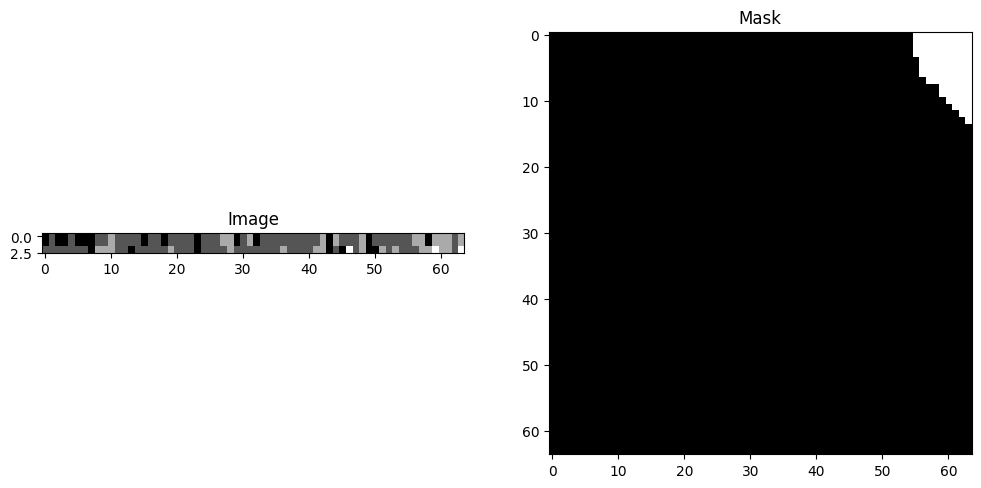

Image shape: torch.Size([3, 64, 64]), Mask shape: torch.Size([64, 64])


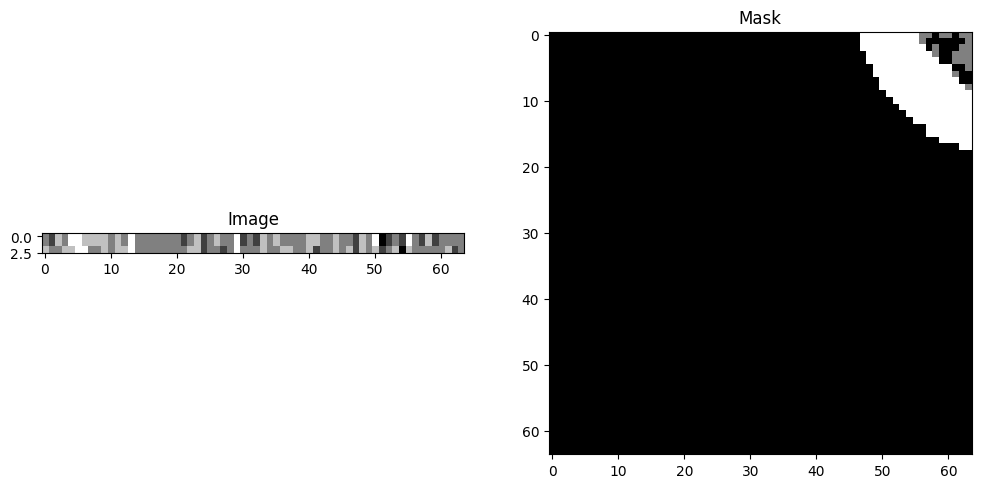

Image shape: torch.Size([3, 64, 64]), Mask shape: torch.Size([64, 64])


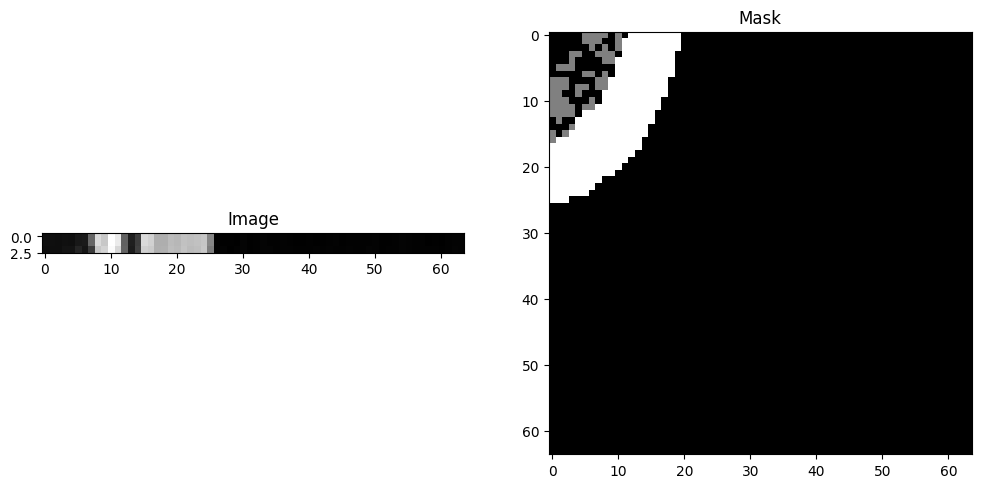

In [17]:
def visualize_patch(dataset, idx):
    sample = dataset[idx]
    image = sample['image']
    mask = sample['mask']
    print(f"Image shape: {image.shape}, Mask shape: {mask.shape}")
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Image")
    plt.imshow(image[..., 0], cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title("Mask")
    plt.imshow(mask, cmap='gray')
    plt.show()

# Visualize a few patches from the training dataset
for i in range(3):
    visualize_patch(train_dataset, i)


# Validate Image Paths

In [18]:
def validate_image_paths(image_paths):
    for path in image_paths:
        path = path.replace("\\", "/")
        if not os.path.exists(path):
            print(f"File does not exist: {path}")
            return False
    return True

# Example usage to validate all input images
input_image_paths = [os.path.join(new_input_dir, name).replace("\\", "/") for name in name_list]
if not validate_image_paths(input_image_paths):
    raise FileNotFoundError("One or more input image files are missing.")


In [19]:
dropout_rate = 0.5
net = UNet_Light_RDN(n_channels=n_channel, n_classes=class_num, dropout_rate=dropout_rate)
net.to(device)

# Log the model
mlflow.pytorch.log_model(net, "model")

c:\Users\n.vanderesse\AppData\Local\ia-sereos_env\lib\site-packages\_distutils_hack\__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


In [20]:
optimizer = Adam(net.parameters(),
                      lr=float(learning_rate),
                      eps=float(epsilon),
                      betas=(0.9, 0.999),
                      weight_decay=weight_decay)

#learning rate schedule
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=period_size, gamma=0.1)

# Journalisation des hyperparamètres de l'optimiseur
mlflow.log_param("optimizer", "Adam")
mlflow.log_param("betas", (0.9, 0.999))


(0.9, 0.999)

# Training loop

In [21]:
#rdn_train train the model for one iteration
# Input : 
# net: The neural network model being trained.
# optimizer: The optimizer used for updating the model's parameters.
# data_loader: DataLoader providing batches of training data.
# epoch: Current epoch number (optional).
# total_epoch: Total number of epochs (optional).
# tensorboard_plot: Boolean flag for visualizing results on TensorBoard (default is False).
#
# Output :
# returns the total number of iterations processed for this epoch (nb_ite + last_batches)

def visualize_images(writer, net, image, mask, device, nb_ite, last_batches, epoch):
    with torch.no_grad():
        pred2 = net(image)

    # Convert tensors to numpy arrays for visualization
    image_np = image.cpu().data.numpy()
    mask_np = mask.argmax(1).cpu().data.numpy()
    pred_np = pred2.argmax(1).cpu().data.numpy()

    # Visualize the first image in the batch for simplicity
    batch_idx = 0
    image_slice = image_np[batch_idx, :, :, :]  # Extract the channels of the image
    mask_slice = mask_np[batch_idx, :, :]       # Extract the mask
    pred_slice = pred_np[batch_idx, :, :]       # Extract the prediction

    # Ensure the arrays are in the correct shape and type
    image_slice = image_slice[0]  # Select the first channel if there's only one channel
    mask_slice = mask_slice.astype(np.uint8)
    pred_slice = pred_slice.astype(np.uint8)

    # Display the images on TensorBoard
    writer.add_image('input_image', torchvision.utils.make_grid(torch.tensor(image_slice)), nb_ite + last_batches)
    writer.add_image('prediction_image', torchvision.utils.make_grid(torch.tensor(pred_slice)), nb_ite + last_batches)
    writer.add_image('mask_image', torchvision.utils.make_grid(torch.tensor(mask_slice)), nb_ite + last_batches)


def rdn_train(net, optimizer, data_loader, epoch=None, total_epoch=None, tensorboard_plot=False, nb_ite=0):
    max_batches1 = len(data_loader.dataset) // data_loader.batch_size + (1 if (len(data_loader.dataset) % data_loader.batch_size) != 0 else 0)
    epoch_print = 'Epoch:'
    if epoch is not None:
        epoch_print += f'{epoch + 1}'
    if total_epoch is not None:
        epoch_print += f'/{total_epoch}'
    last_batches = 0.0
    loss1_sum = 0.0
    loss2_sum = 0.0
    ite = 0
    writer = SummaryWriter(runs_dir)
    with tqdm(total=len(data_loader.dataset), desc=epoch_print, unit=' batches') as pbar:
        for i_batches, sample_batched in enumerate(data_loader):
            # Skip the last batch if it's not a full batch
            if sample_batched['image'].size(0) != data_loader.batch_size:
                continue
            last_batches = i_batches
            mask = sample_batched['mask']
            image = sample_batched['image']
            mask = mask.to(device).long()
            image = image.to(device)
            pred = net(image)
            loss1 = torch.Tensor(0)
            mask = create_one_hot(mask)
            if tensorboard_plot and nb_ite + ite == 0:
                writer.add_graph(net, image)
            if tensorboard_plot and (ite % (max_batches1 // 3) == 0):
                visualize_images(writer, net, image, mask, device, nb_ite, last_batches, epoch)
            CE_loss = nn.CrossEntropyLoss()
            loss2 = CE_loss(pred, mask)
            loss2.to(device)
            optimizer.zero_grad()
            loss2.backward()
            optimizer.step()
            pbar.update(mask.shape[0])
            pbar.set_postfix(loss=loss2.cpu().data.numpy(), loss1=loss1.cpu().data.numpy(), loss2=loss2.cpu().data.numpy())
            loss1_sum += loss1.cpu().data.numpy()
            loss2_sum += loss2.cpu().data.numpy()
            ite += 1
        avg_loss2 = loss2_sum / (last_batches + 1)
        print(f'\nAverage, loss2: {(loss2_sum / (last_batches + 1)):.6f}.')
        mlflow.log_metric("avg_train_loss2", avg_loss2, step=epoch)
    #writer.close()
    return nb_ite + last_batches



#rdn_val test the accuracy of the model for the current epoch
# Input :
# net: The neural network model.
# data_set: The dataset for validation.
# i_epoch: Current epoch number (optional).
# class_num: Number of classes in the dataset (default is 3).
#
# Output :
# returns the average accuracy (criterion_value) and class-wise dice overlap results.

class DiceOverlap():
    def __init__(self, class_num):
        self.len = class_num

    def __call__(self, input, target):
        input = F.sigmoid(input)
        input = torch.max(input, 1)[1]

        dice = []

        for i in range(self.len):
            sub_target = torch.zeros(target.shape).cuda()
            sub_target[target == i] = 1
            sub_input = torch.zeros(input.shape).cuda()
            sub_input[input == i] = 1

            tp_idx = target == i

            eps = 0.0001
            tp = torch.sum(sub_input[tp_idx] == sub_target[tp_idx])
            fn = torch.sum(sub_input != sub_target)
            tp = tp.float()
            fn = fn.float()
            result = (2 * tp + eps) / (2 * tp + fn + eps)
            dice.append(result.cpu().data.numpy())

        return np.asarray(dice)


class Accuracy():
    def __call__(self, input, target, **kwargs):
        input = torch.max(input, 1)[1]
        size = 1
        for i in range(len(input.shape)):
            size = size * input.shape[i]
        return torch.sum(input == target).float() / size

def rdn_val(net, data_set, i_epoch=None, class_num=3):
    dice_overlap = DiceOverlap(class_num)

    origin_is_train_mode = net.training
    if origin_is_train_mode:
        net.eval()

    data_set.set_mode('val')

    criterion_value_sum = 0.0
    data_loader = DataLoader(data_set, batch_size=1, num_workers=0)
    dice_overlap_results = np.zeros(class_num)

    for i_batches, sample_batched in enumerate(data_loader):
        mask = sample_batched['mask']
        image = sample_batched['image']

        mask = mask.to(device)
        image = image.to(device)

        with torch.no_grad():
            pred = net(image)
            criterion_value_sum += Accuracy()(pred, mask.long()).cpu().data.numpy()

            if dice_overlap is not None:
                dice_result = dice_overlap(pred, mask.long())
                dice_overlap_results += dice_result

                # Debugging prints
                #print(f'Batch {i_batches}:')
                #print(f'    Dice result: {dice_result}')
                #print(f'    Pred shape: {pred.shape}, Pred unique values: {torch.unique(pred)}')
                #print(f'    Mask shape: {mask.shape}, Mask unique values: {torch.unique(mask)}')

    criterion_value = criterion_value_sum / len(data_loader.dataset)
    dice_overlap_results = dice_overlap_results / len(data_loader.dataset)

    #for i in range(len(dice_overlap_results)):
    #    print(f'Class: {i}, Dice Overlap: {dice_overlap_results[i]}')

    if origin_is_train_mode:
        net.train()

    mlflow.log_metric("val_accuracy", criterion_value, step=i_epoch)
    for i in range(dice_overlap_results.shape[0]):
        mlflow.log_metric(f"dice_overlap_class_{i}", dice_overlap_results[i], step=i_epoch)
        nested_metrics['val_accuracy'].append(criterion_value)
        nested_metrics[f'dice_overlap_class_{i}'].append(dice_overlap_results[i])

    if i_epoch is not None:
        print(f"Epoch: {i_epoch + 1}, Accuracy Value: {criterion_value:.6f}")
        writer.add_scalar('Accuracy Value', criterion_value, i_epoch)
        writer.add_scalars('Dice Overlap', {
            'Air': dice_overlap_results[0], 
            'Dirt': dice_overlap_results[1], 
            'Bone': dice_overlap_results[2]
        }, i_epoch)

    return criterion_value, dice_overlap_results








In [22]:
# Training loop
nested_metrics = {
    'train_loss': [],
    'val_accuracy': [],
    'dice_overlap_class_0': [],
    'dice_overlap_class_1': [],
    'dice_overlap_class_2': []
}

epoch_count = 0
print(f"Epoch progress:")
print(f"Progress training {epochs_num} epochs...")
total_timer = timer()
iteration = 0
nb_ite = 0

# Training loop
for i_epoch in range(epochs_num):
    nested_runs_dir = os.path.join(runs_dir, f"epoch_{i_epoch + 1}")
    writer = SummaryWriter(nested_runs_dir)
    with mlflow.start_run(nested=True, run_name=f"epoch_{i_epoch + 1}"):
        print(f"Epoch {epoch_count + 1} of {epochs_num}")

        # Dynamic air rate based on epoch
        if i_epoch < period_size:
            air_rate = 0.1
        elif i_epoch < 2 * period_size:
            air_rate = 0.2
        elif i_epoch < 3 * period_size:
            air_rate = 0.4
        else:
            air_rate = 0.5

        mlflow.log_param("air_rate", air_rate)

        # Get patches 
        patches = get_minimum_dirt_patches(dirt_choose_threshold=0.1, dirt_rate=0, patches=train_patches, ratios=ratios)

        DEB_patches, index = get_dirt_bone_patches(train_patches, ratios, air_rate)
        DEB_patches = pd.DataFrame(DEB_patches)

        data_set = HDF52D(patches, mode='train', transform=train_transform)
        DEB_data_set = HDF52D(DEB_patches.values.tolist(), mode='train', transform=train_transform)

        current_batch = int(batch_size)
        train_data_loader = DataLoader(dataset=DEB_data_set, batch_size=current_batch, shuffle=True, num_workers=0, drop_last=True)

        print(f"learning rate {optimizer.param_groups[0]['lr']:.6f}")
        nb_ite = rdn_train(net, optimizer, train_data_loader, epoch=i_epoch, total_epoch=epochs_num, tensorboard_plot=True, nb_ite=nb_ite)

        # Switch dataset to validation mode
        set_dataset_mode(data_set, mode='val')

        # Validating
        val_loss, class_val = rdn_val(net, data_set, i_epoch=i_epoch, class_num=class_num)

        # Collect validation metrics for the current epoch
        nested_metrics['val_accuracy'].append(val_loss)
        for i, class_val_metric in enumerate(class_val):
            nested_metrics[f'dice_overlap_class_{i}'].append(class_val_metric)

        class_val = pd.DataFrame(class_val)
        class_val.columns = ["Class Dice overlap"]
        print(class_val)
        epoch_count += 1
        iteration = np.floor((100 * epoch_count) / int(epochs_num))

# Save model
torch.save(net.state_dict(), "RDN_adapted.pth")

# Aggregate and log metrics from nested runs to the main run
avg_train_loss = np.mean(nested_metrics['train_loss'])
avg_val_accuracy = np.mean(nested_metrics['val_accuracy'])
avg_dice_overlap_class_0 = np.mean(nested_metrics['dice_overlap_class_0'])
avg_dice_overlap_class_1 = np.mean(nested_metrics['dice_overlap_class_1'])
avg_dice_overlap_class_2 = np.mean(nested_metrics['dice_overlap_class_2'])

mlflow.log_metric("avg_train_loss", avg_train_loss)
mlflow.log_metric("avg_val_accuracy", avg_val_accuracy)
mlflow.log_metric("avg_dice_overlap_class_0", avg_dice_overlap_class_0)
mlflow.log_metric("avg_dice_overlap_class_1", avg_dice_overlap_class_1)
mlflow.log_metric("avg_dice_overlap_class_2", avg_dice_overlap_class_2)

# End MLflow run
mlflow.end_run()

# Close the TensorBoard writer
writer.close()


Epoch progress:
Progress training 4 epochs...
Epoch 1 of 4
There are 1327 bone and 0 dirt patches in the training data...
learning rate 0.001000


Epoch:1/4:   0%|          | 0/1327 [00:00<?, ? batches/s]C:\Users\n.vanderesse\AppData\Local\Temp\ipykernel_26576\3280858929.py:65: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  diffY = torch.tensor([x2.size()[2] - x1.size()[2]])
C:\Users\n.vanderesse\AppData\Local\Temp\ipykernel_26576\3280858929.py:66: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  diffX = torch.tensor([x2.size()[3] - x1.size()[3]])
Epoch:1/4:  99%|█████████▉| 1312/1327 [00:21<00:00, 60.28 batches/s, loss=0.332


Average, loss2: 0.521239.
Epoch: 1, Accuracy Value: 0.876573
   Class Dice overlap
0            0.931861
1            0.316005
2            0.132789
Epoch 2 of 4
There are 1327 bone and 0 dirt patches in the training data...
learning rate 0.001000


Epoch:2/4:  99%|█████████▉| 1312/1327 [00:18<00:00, 71.02 batches/s, loss=0.23513958, loss1=[], loss2=0.23513958]



Average, loss2: 0.274784.
Epoch: 2, Accuracy Value: 0.937161
   Class Dice overlap
0            0.984891
1            0.423373
2            0.640884
Epoch 3 of 4
There are 1327 bone and 0 dirt patches in the training data...
learning rate 0.001000


Epoch:3/4:  99%|█████████▉| 1312/1327 [00:18<00:00, 70.64 batches/s, loss=0.2150606, loss1=[], loss2=0.2150606]  



Average, loss2: 0.236106.
Epoch: 3, Accuracy Value: 0.978801
   Class Dice overlap
0            0.989420
1            0.567926
2            0.904682
Epoch 4 of 4
There are 1327 bone and 0 dirt patches in the training data...
learning rate 0.001000


Epoch:4/4:  99%|█████████▉| 1312/1327 [00:17<00:00, 76.23 batches/s, loss=0.20577884, loss1=[], loss2=0.20577884]



Average, loss2: 0.221337.
Epoch: 4, Accuracy Value: 0.974397
   Class Dice overlap
0            0.992526
1            0.568869
2            0.843139


c:\Users\n.vanderesse\AppData\Local\ia-sereos_env\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\n.vanderesse\AppData\Local\ia-sereos_env\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [23]:
# After training
val_loss, class_val = rdn_val(net, val_dataset, i_epoch=1, class_num=class_num)

# Check results
print(f'Validation Loss: {val_loss}')
for i, dice in enumerate(class_val):
    print(f'Dice Overlap for class {i}: {dice}')


Epoch: 2, Accuracy Value: 0.980565
Validation Loss: 0.9805645184913158
Dice Overlap for class 0: 0.9949251992473193
Dice Overlap for class 1: 0.5063705904557234
Dice Overlap for class 2: 0.9139412465022747
